<a href="https://colab.research.google.com/github/IsaacKosloski/masters-LinearSystemsTheory/blob/main/TSL00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy import signal
import scipy.linalg as la
import sympy
import matplotlib.pyplot as plt

!pip install git+https://github.com/python-control/python-control.git
import control as ct

  Cloning https://github.com/python-control/python-control.git to /tmp/pip-req-build-lsq1m6sf
  Running command git clone --filter=blob:none --quiet https://github.com/python-control/python-control.git /tmp/pip-req-build-lsq1m6sf
  Resolved https://github.com/python-control/python-control.git to commit 854f5f7159bc7e4537c82af4c09c7a225d58444d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for control: filename=control-0.10.3.dev13+g854f5f715-py3-none-any.whl size=578656 sha256=d65888307c365d6f876452a4e118895ca2619c9c416f4565660faba113cb256e
  Stored in directory: /tmp/pip-ephem-wheel-cache-0wo3wm_x/wheels/2e/55/a6/165b0cb0bfd636c9b19ed3f4ba5263fb9d974edc1a2b8d4e87
Successfully built control


In [ ]:
# Physical Parameters
m, k1, k2 = 1.0, 3.0, 2.0

# State-space matrices
A = np.array([[0, 1],
              [-k2/m, -k1/m]])
B = np.array([[0],
              [1/m]])
C = np.array([[1, 0]]) # Output: displacement
D = np.array([[0]])

# Define system using control library
sys_mech = ct.ss(A, B, C, D)

# Convert to Transfer Function
tf_mech = ct.ss2tf(sys_mech).minreal()
print(f"Transfer Function:\n{tf_mech}")
# Expected output: 1 / (s^2 + 3s + 2)

Transfer Function:
<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  8.882e-16 s + 1
  ---------------
   s^2 + 3 s + 2


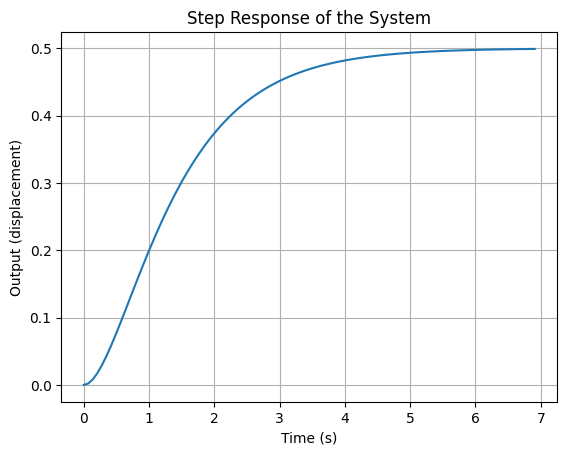

In [ ]:
# Create a control system object from the state-space matrices
sys_control = ct.ss(A, B, C, D)

# Simulate the step response
t, y = ct.step_response(sys_control)

# Plot the step response
plt.figure()
plt.plot(t, y)
plt.xlabel('Time (s)')
plt.ylabel('Output (displacement)')
plt.title('Step Response of the System')
plt.grid()
plt.show()